Business case Introduction

Cars24 is one of the leading used-car buying and selling platform in India.

* Current methodology to estimate the selling price has three major components
* Past records of the "Selling Prices" of the same Make and Model
* Rule based calculations for the depreciation of the car
* Rule based calculation for condition of the vehicle
* As the Pricing Data Scientist working at Cars24, you are given a task

GOAL: To automate the process of estimating price of the used car

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [ ]:
df = pd.read_csv("E:/My-CodeBase/Data-Science-Portfolio/machine_learning_projects/cars24-car-price.csv")
df.head()

,full_name,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Maruti Alto Std,1.20,2012.0,Individual,120000,Petrol,Manual,19.70,796.0,46.30,5.0
1,Hyundai Grand i10 Asta,5.50,2016.0,Individual,20000,Petrol,Manual,18.90,1197.0,82.00,5.0
2,Hyundai i20 Asta,2.15,2010.0,Individual,60000,Petrol,Manual,17.00,1197.0,80.00,5.0
3,Maruti Alto K10 2010-2014 VXI,2.26,2012.0,Individual,37000,Petrol,Manual,20.92,998.0,67.10,5.0
4,Ford Ecosport 2015-2021 1.5 TDCi Titanium BSIV,5.70,2015.0,Dealer,30000,Diesel,Manual,22.77,1498.0,98.59,5.0


In [ ]:
df.shape

(19980, 11)

In [ ]:
display(df.describe())

,selling_price,year,km_driven,mileage,engine,max_power,seats
count,19980.000000,19980.000000,1.998000e+04,19980.000000,19980.000000,19980.000000,19980.000000
mean,7.392066,2014.525125,5.824488e+04,19.347219,1476.327401,97.854443,5.317868
std,9.103088,3.249185,5.172509e+04,4.620053,520.449398,45.080670,0.835370
min,0.250000,1991.000000,1.000000e+02,0.000000,0.000000,5.000000,2.000000
25%,3.400000,2013.000000,3.116425e+04,16.800000,1197.000000,73.900000,5.000000
50%,5.200000,2015.000000,5.200000e+04,19.160000,1248.000000,86.700000,5.000000
75%,7.850000,2017.000000,7.400000e+04,22.320000,1582.000000,112.000000,5.000000
max,395.000000,2021.000000,3.800000e+06,120.000000,6752.000000,626.000000,14.000000


* selling_price ranges from (0.25, 395) - the value seems to be in lakhs.
* mileage min 0 to max 120 - need to check for outliers.
* engine min 0 to max 6752 - values appears to be in "cc" - needs to check for outliers.

Distributions for abhove each of features

<Axes: >

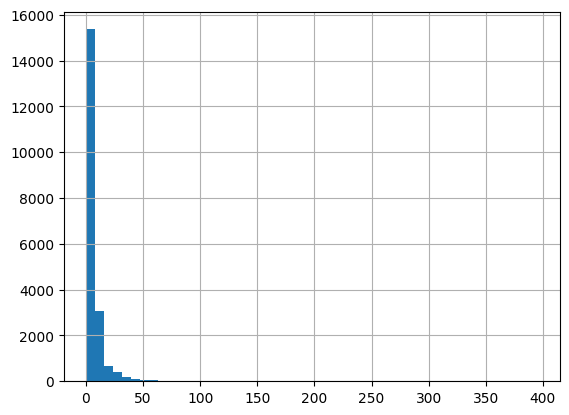

In [ ]:
df["selling_price"].hist(bins=50)

Lets check percentage of outlies above the 100k as looking at above plot over 100k price  

In [ ]:
#Lets check the percntage of outliers. We are manually taking a call that price over a 100 (K) is an outlier by looking at the above plot

(df.loc[df.selling_price > 100].shape[0] / df.shape[0]) * 100

0.055055055055055056

In [ ]:
# Lets saturate selling price at 100.
df.loc[df.selling_price > 100, 'selling_price'] = 100

Outliers and Missing Values
Q: Which plot(s) is/are suitable for outlier visualisation ?

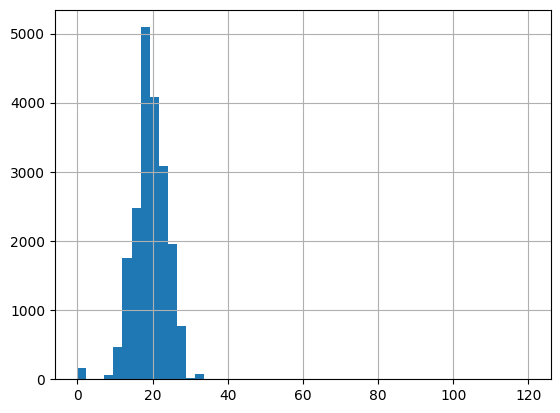

In [ ]:
df["mileage"].hist(bins=50);

Another useful plot is called the 'density' plot. Which is also similar to histogram, but with a more approximate shape. It tries to fit a suitable distribution over the histogram and hence includes points that might not even be present in data at hand.

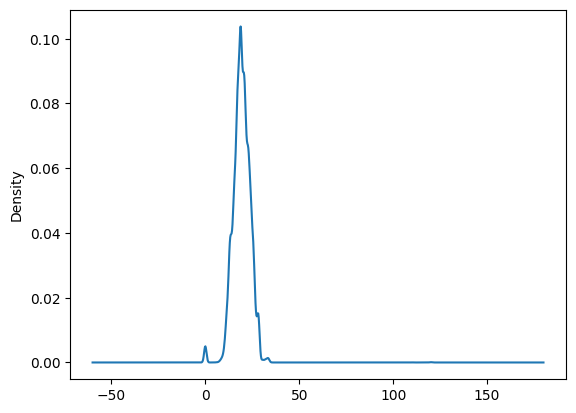

In [ ]:
df["mileage"].plot.density();

We observe a skewed plot with right tail to long. An interesting point here would be mileage > 40, because after that it looks like the values mught just be outliers.

Above we saw that there was an unusual peak at 0. Lets investigate further. Looking at points where mileage is less than 5

In [ ]:
df[df["mileage"]<=5].mileage.describe()

count    161.000000
mean       0.024845
std        0.315244
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        4.000000
Name: mileage, dtype: float64

Looks like we just have a number of points with mileage 0. That does not make much sense as it cannot be a real value for car mileage. Investigating mileage=0 cases

In [ ]:
df.loc[df.mileage == 0].shape[0] / df.shape[0] # 0.8 %

0.008008008008008008

In [ ]:
df[df["mileage"] == 0.0].shape

(160, 11)

Thats a very small number of points. We can safely impute, or drop these points later during pre-processing

Are the top values errorneous?

Above we had also noticed that there was a significant point at mileage=40. After this there were only very few points and looked like outliers. Lets check them

In [ ]:
df[df["mileage"] > 40].mileage.describe()

count      4.0
mean     117.5
std        5.0
min      110.0
25%      117.5
50%      120.0
75%      120.0
max      120.0
Name: mileage, dtype: float64

In [ ]:
df[df["mileage"] > 40]

,full_name,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats
11966,Mahindra e2oPlus P6,4.00,2018.0,Dealer,26000,Electric,Automatic,110.0,1476.327401,25.4,4.0
15684,Mahindra e2o T2,3.60,2015.0,Dealer,42862,Electric,Automatic,120.0,0.000000,25.5,5.0
17782,Mahindra e2o T2,4.50,2015.0,Dealer,40000,Electric,Automatic,120.0,0.000000,25.5,5.0
18401,Mahindra e2o Premium,3.25,2013.0,Individual,50000,Electric,Automatic,120.0,0.000000,25.5,5.0


In [ ]:
df[df["mileage"] > 40].fuel_type.value_counts()

fuel_type
Electric    4
Name: count, dtype: int64

So all vehicles with mileage > 40 are electric vehicles which makes sense.
So they are not incorrect (error) values.
Let us not remove these points for now

Correlations

Now lets look at the correlations of numerical features with each other

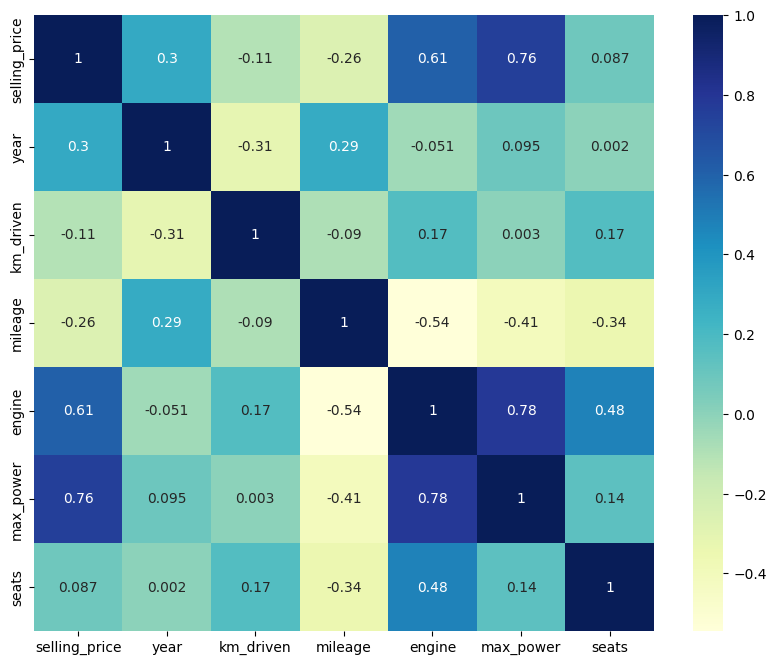

In [ ]:
plt.figure(figsize=(10,8))
ax = sns.heatmap(df.corr(numeric_only=True), cmap="YlGnBu", annot=True)

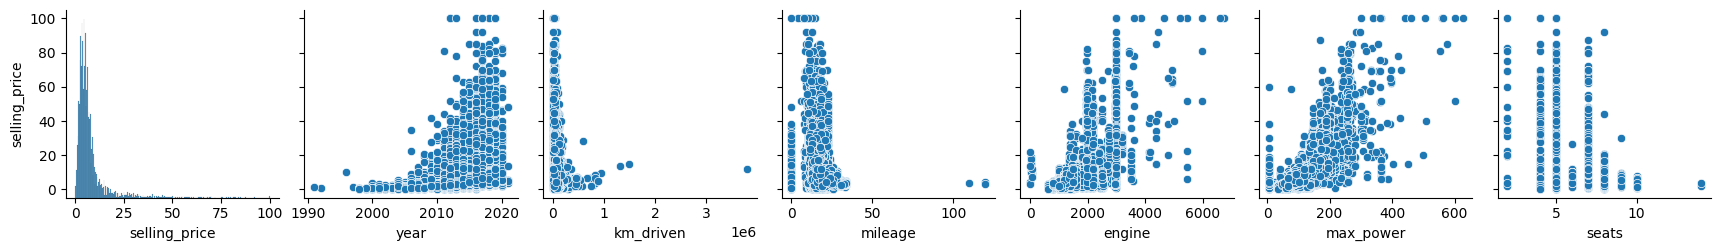

In [ ]:
sns.pairplot(df, y_vars=["selling_price"]);

In [ ]:
df['seats'].value_counts(normalize=True)

seats
5.0     0.834885
7.0     0.118619
8.0     0.022022
4.0     0.011261
6.0     0.007157
9.0     0.003604
10.0    0.001301
2.0     0.001051
14.0    0.000100
Name: proportion, dtype: float64

Categorical Variables

How can we extract Make and Model from "full_name"
We have noticed that the name contains the informaiton of the brand and the model. Lets extract those and create new features from them. After that we can drop the original column

In [ ]:
df["company"] = df.full_name.apply(lambda x : x.split()[0])
df["model"] = df.full_name.apply(lambda x : " ".join(x.split()[1:]))
df = df.drop("full_name", axis=1)
df.head(2)

,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats,company,model
0,1.2,2012.0,Individual,120000,Petrol,Manual,19.7,796.0,46.3,5.0,Maruti,Alto Std
1,5.5,2016.0,Individual,20000,Petrol,Manual,18.9,1197.0,82.0,5.0,Hyundai,Grand i10 Asta


Now let us look at some categorical variables one by one

In [ ]:
display(df.describe(include="object"))

C:\Windows\Temp\ipykernel_12552\1391311326.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,seller_type,fuel_type,transmission_type,company,model
count,19980,19980,19980,19980,19980
unique,3,5,2,42,3321
top,Dealer,Diesel,Manual,Maruti,Swift Dzire VDI
freq,11973,9817,16029,5650,210


In [ ]:
df["fuel_type"].value_counts()

fuel_type
Diesel      9817
Petrol      9767
CNG          316
LPG           66
Electric      14
Name: count, dtype: int64

In [ ]:
df['transmission_type'].value_counts()

transmission_type
Manual       16029
Automatic     3951
Name: count, dtype: int64

In [ ]:
df['seller_type'].value_counts()

seller_type
Dealer              11973
Individual           7817
Trustmark Dealer      190
Name: count, dtype: int64

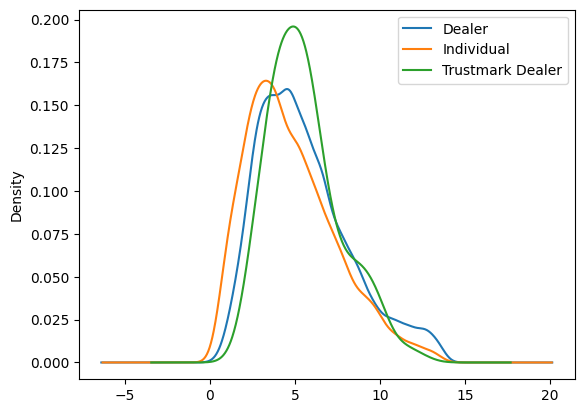

In [ ]:
# Does selling price vary in some of these groups
df.loc[df.selling_price<=df.selling_price.quantile(0.9)].groupby('seller_type')['selling_price'].plot.density()
plt.legend()

Looks like for different seller type, the selling price distrubution is not very different. Hence one intuition that can be developed from this plot is that the seller_type variable will not turn out to be very important for the ML model. (We will check this later)

seller_type
Dealer              Axes(0.125,0.11;0.775x0.77)
Individual          Axes(0.125,0.11;0.775x0.77)
Trustmark Dealer    Axes(0.125,0.11;0.775x0.77)
Name: selling_price, dtype: object

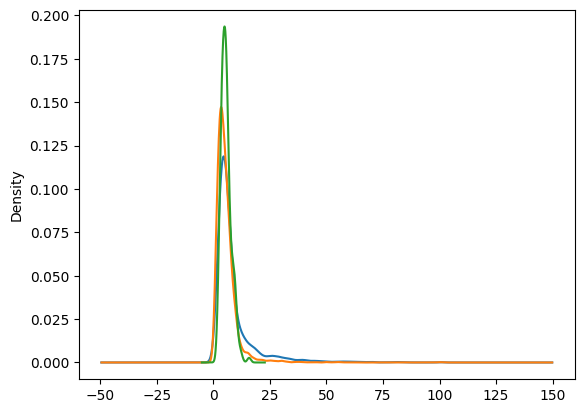

In [ ]:
df['selling_price'].groupby(df['seller_type']).plot.density()

Lets check for all groups?
Another way to visualise the same is to use a plot known as box-plot

Note: Although, seats is numeric, but we will consider it as an ordinal variable and perform similar analysis as we do for other categorical variables.

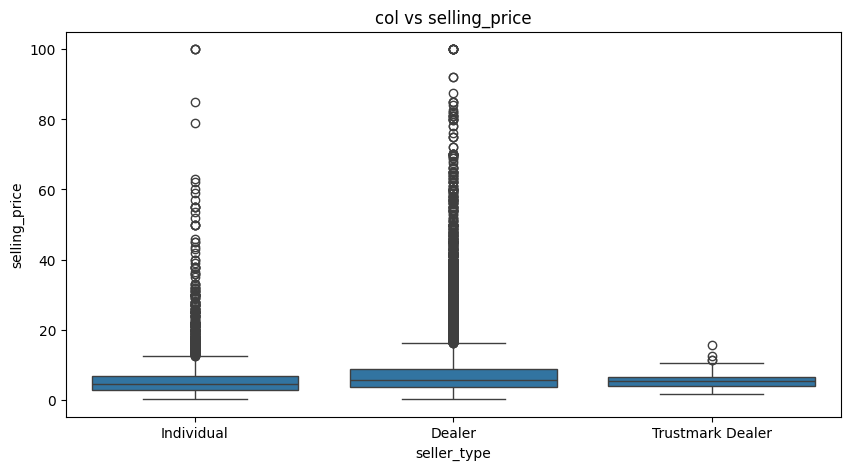

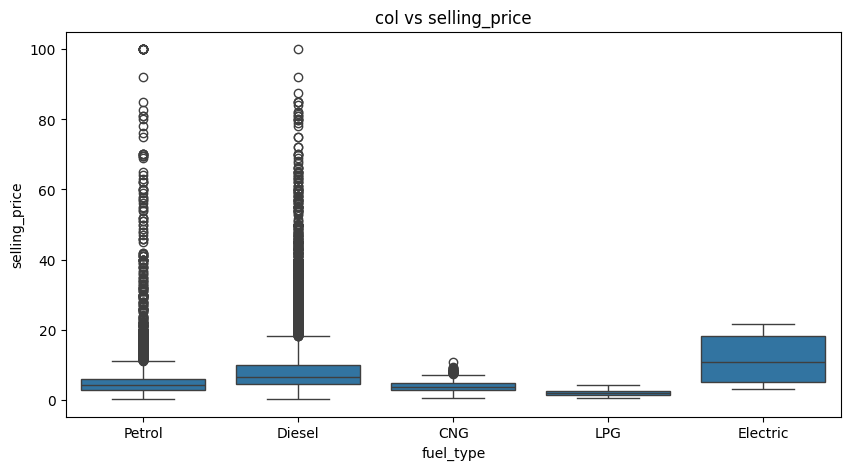

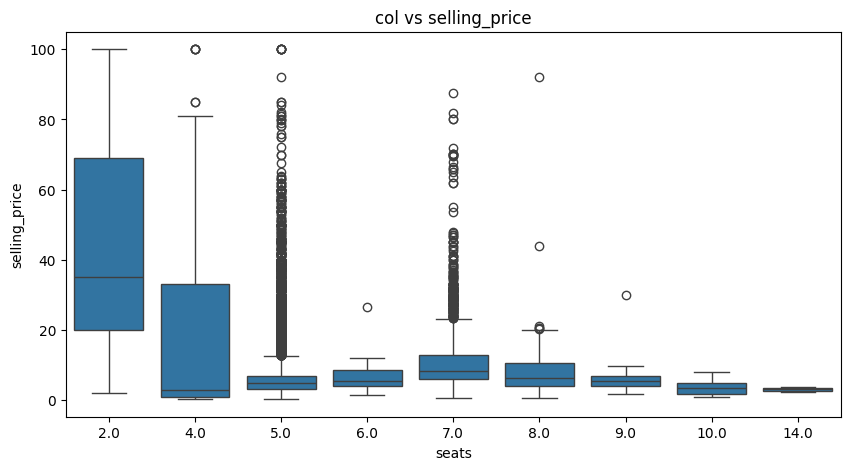

In [ ]:
for col in ['seller_type', 'fuel_type', 'seats']:
    plt.figure(figsize=(10,5))
    sns.boxplot(y='selling_price', x=col, data=df)
    plt.title('col vs selling_price')
    plt.show()


In [ ]:
len(df['company'].unique())

42

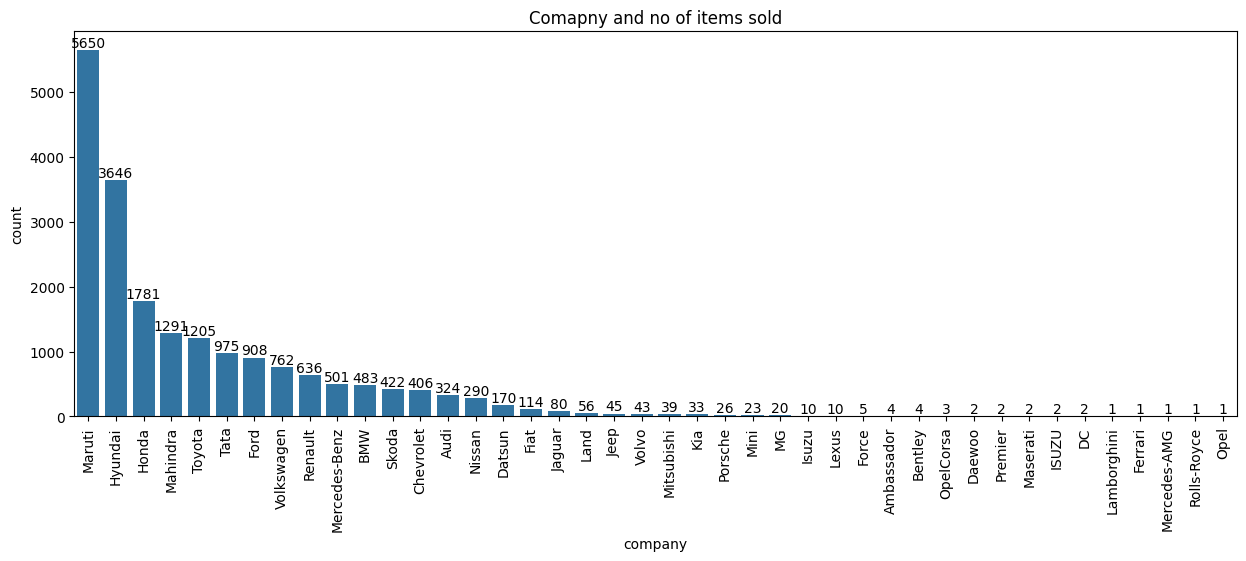

In [ ]:
plt.figure(figsize=(15,5))
ax = sns.countplot(x='company', data=df, order = df['company'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Comapny and no of items sold")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


How is "make" related to the selling price?

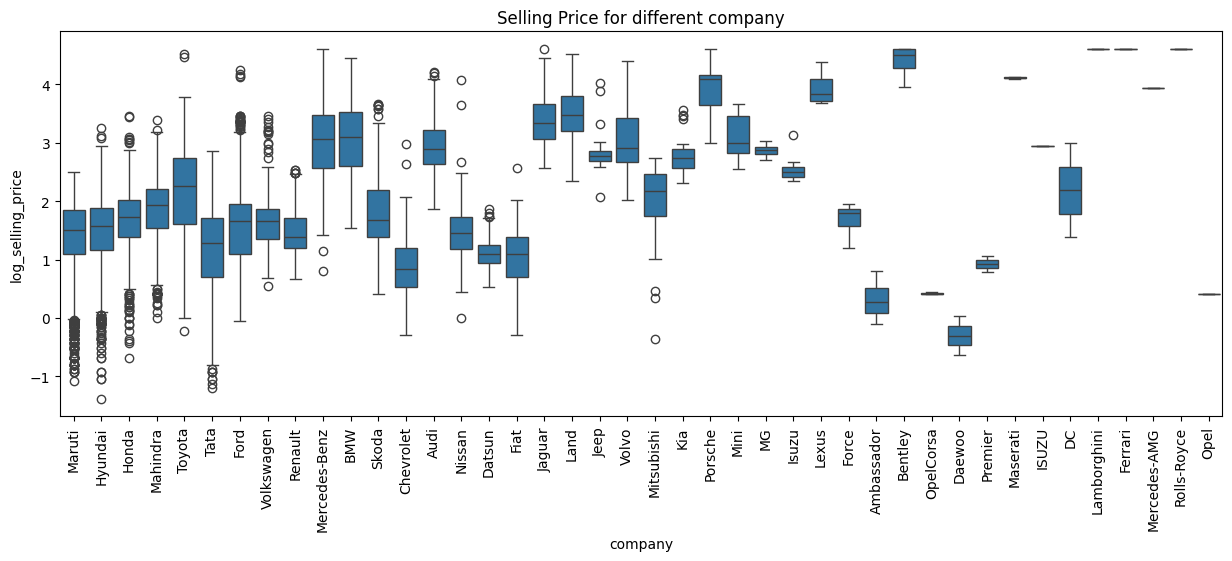

In [ ]:
df["log_selling_price"] = np.log(df["selling_price"].values)
plt.figure(figsize=(15,5))
sns.boxplot(y='log_selling_price',x='company', data=df, order = df['company'].value_counts().index)
plt.xticks(rotation=90);
plt.title("Selling Price for different company")
plt.show()

In [ ]:
df.drop("log_selling_price", axis=1, inplace=True)

How should we treat number of seats? Continuous OR Categorical ?

Number of seats is a variable with a finite discrete set of values. However it is orderd. If we make it categorical, it would be fed into the model as unordered.

But we need to think do we want that order?

Example: 2 seater cars are most likely more expensive than other cars. So in this sense 2 > 5. We actually would benefit from discarding the order.

Feature Engineering

In [ ]:
df.head()

,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats,company,model
0,1.20,2012.0,Individual,120000,Petrol,Manual,19.70,796.0,46.30,5.0,Maruti,Alto Std
1,5.50,2016.0,Individual,20000,Petrol,Manual,18.90,1197.0,82.00,5.0,Hyundai,Grand i10 Asta
2,2.15,2010.0,Individual,60000,Petrol,Manual,17.00,1197.0,80.00,5.0,Hyundai,i20 Asta
3,2.26,2012.0,Individual,37000,Petrol,Manual,20.92,998.0,67.10,5.0,Maruti,Alto K10 2010-2014 VXI
4,5.70,2015.0,Dealer,30000,Diesel,Manual,22.77,1498.0,98.59,5.0,Ford,Ecosport 2015-2021 1.5 TDCi Titanium BSIV


1. Year
Sometimes it is good practice to convert the features into the way we actually understand. This will not necessarily help the model, but helps in us in understanding / interpreting predictions little better

So lets convert year to more readable age

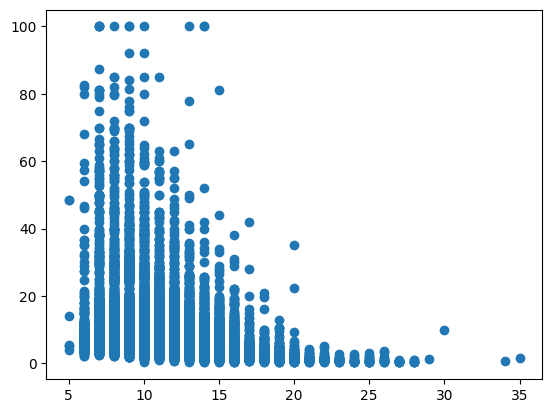

In [ ]:
current_year = datetime.now().year
age = current_year - df['year']
plt.scatter(age, df.selling_price)
plt.show()

Higher Selling Price for Newer Cars!!!!

2. Categorical Encoding
Q: How do we encode categorical variables for modelling?
2.1 transmission_type (2 categories)

In [ ]:
# explains how two category variable can be encoded as a binary variable
transmission_dummy = pd.get_dummies(df["transmission_type"])
df = pd.concat([df, transmission_dummy], axis=1)
df = df.drop(["transmission_type", "Automatic"], axis=1)
df = df.rename(columns={"Manual": "transmission_type"})
df.sample(frac=1).head(2)

,selling_price,year,seller_type,km_driven,fuel_type,mileage,engine,max_power,seats,company,model,transmission_type
17524,5.3,2018.0,Individual,20000,Petrol,17.8,1198.0,86.70,5.0,Honda,Amaze S i-VTEC,True
12625,5.5,2019.0,Individual,35000,Petrol,19.5,1199.0,88.76,5.0,Honda,Amaze E Petrol BSIV,True


2.2 fuel_type (5 categores)

In [ ]:
fuel_type_dummy = pd.get_dummies(df["fuel_type"], prefix="seats")
fuel_type_dummy.sample(frac=1).head(2)

,seats_CNG,seats_Diesel,seats_Electric,seats_LPG,seats_Petrol
17892,False,True,False,False,False
10778,False,True,False,False,False


NOTE: We remove 1 of the dummy variables to avoid the dummy variable trap

In [ ]:
fuel_type_dummy = fuel_type_dummy[fuel_type_dummy.columns[1:]]
fuel_type_dummy.head(2)

,seats_Diesel,seats_Electric,seats_LPG,seats_Petrol
0,False,False,False,True
1,False,False,False,True


In [ ]:
pd.concat([df, fuel_type_dummy], axis=1).sample(frac=1).head(2)

,selling_price,year,seller_type,km_driven,fuel_type,mileage,engine,max_power,seats,company,model,transmission_type,seats_Diesel,seats_Electric,seats_LPG,seats_Petrol
18519,8.0,2013.0,Individual,80000,Diesel,22.32,1582.0,126.32,5.0,Hyundai,Verna 1.6 SX,True,True,False,False,False
6074,2.3,2008.0,Individual,110000,Diesel,18.10,1493.0,110.00,5.0,Hyundai,Verna CRDi SX ABS,True,True,False,False,False


2.3 make (too many categoies)

In [ ]:
df.company.nunique()

42

INTERACTION

How to handle so many categories? Hint: Here we have too many categories. We can merge categories as in 'seats' variable or we can try target encoding. Dummy encoding would make too many features with highly diluted information.
Or we can try another technique known as Target Encoding

In [ ]:
encoded_company = df.groupby('company')['selling_price'].transform('mean')

In [ ]:
show_df = df[['company']].copy()
show_df['encoded_company'] = encoded_company
show_df = show_df.drop_duplicates()
print(len(show_df))
show_df.head()

42


,company,encoded_company
0,Maruti,4.684721
1,Hyundai,5.374923
4,Ford,6.265275
9,Mahindra,7.303129
10,Tata,4.395415


3. Scaling
Q: Now, All these variables have different ranges. Does that work?

In [ ]:
df.describe()

,selling_price,year,km_driven,mileage,engine,max_power,seats
count,19980.000000,19980.000000,1.998000e+04,19980.000000,19980.000000,19980.000000,19980.000000
mean,7.353527,2014.525125,5.824488e+04,19.347219,1476.327401,97.854443,5.317868
std,8.312958,3.249185,5.172509e+04,4.620053,520.449398,45.080670,0.835370
min,0.250000,1991.000000,1.000000e+02,0.000000,0.000000,5.000000,2.000000
25%,3.400000,2013.000000,3.116425e+04,16.800000,1197.000000,73.900000,5.000000
50%,5.200000,2015.000000,5.200000e+04,19.160000,1248.000000,86.700000,5.000000
75%,7.850000,2017.000000,7.400000e+04,22.320000,1582.000000,112.000000,5.000000
max,100.000000,2021.000000,3.800000e+06,120.000000,6752.000000,626.000000,14.000000


Lets scale this data. We will use MinMaxScaler here (in practice you can choose your scaling techniques depending on the problem, or just try all and see what works best)

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler()
scaler.fit(df[['selling_price', 'km_driven', 'mileage']])
scaled_values = scaler.transform(df[['selling_price', 'km_driven', 'mileage']])  # returns numpy.ndarray not df.
scaled_df = pd.DataFrame(scaled_values, columns=['selling_price', 'km_driven', 'mileage'])
scaled_df.head()

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
scaled_df.describe()

Stichting it all together

In [ ]:
def merge_seats(x):
    if 2 <= x <= 4:
        return '2-4'
    elif x > 5:
        return '>5'
    else:
        return '5'

def preprocess(df):
    df = df.loc[df.mileage != 0].copy()
    outlier_theshold = df.selling_price.quantile(0.95)
    df.loc[df.selling_price > outlier_theshold, 'selling_price'] = outlier_theshold
    df['age'] = pd.to_datetime('now', utc=True).date().year - df['year']
    df['full_name'] = df['full_name'].str.upper()
    df['seats'] = df['seats'].apply(merge_seats)
    df.drop(columns=['year'])
    return df

def feature_engineering(df):
    df['make'] = df.full_name.apply(lambda x : x.split()[0])
    df['model'] = df.full_name.apply(lambda x : " ".join(x.split()[1:]))
    one_hot_encode_cols = ['seller_type', 'fuel_type', 'transmission_type', 'seats']
    for column in one_hot_encode_cols:
        df = pd.concat([df, pd.get_dummies(df[column]).iloc[: , 1:]], axis=1)
    df.drop(columns=one_hot_encode_cols + ['full_name'], inplace=True)
    df['make'] = df.groupby('make')['selling_price'].transform('median')
    df['model'] = df.groupby('model')['selling_price'].transform('median')
    scaler = MinMaxScaler()
    df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    return df

In [ ]:
df = pd.read_csv("cars24-car-price.csv")
df = preprocess(df)
df = feature_engineering(df)
df.head()

In [ ]:
df.shape

In [ ]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), cmap="YlGnBu", annot=True)

max_power, engine and transmission_type are hightest correlated with selling_price in same order.
New encoded features are weak predictor, but they together would might make strong predictors.